# 3D Metrics

To assess segmentation performance in 3D, we can use metrics from the `vl` (volume) accessor.

**NOTE:** This module is still experimental and will change substantially in upcoming releases.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import colormaps
import segtraq

sdata = sd.read_zarr("../../data/proseg2.zarr")

/tmp/ipykernel_499448/466010427.py:11: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr("../../data/proseg2.zarr")
no parent found for <ome_zarr.reader.Label object at 0x7ffd24249710>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffd042fcb50>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffd04735150>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffd2466a2d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffd2423c050>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffd2426a6d0>: None


/tmp/ipykernel_499448/4165430437.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", n_ids)


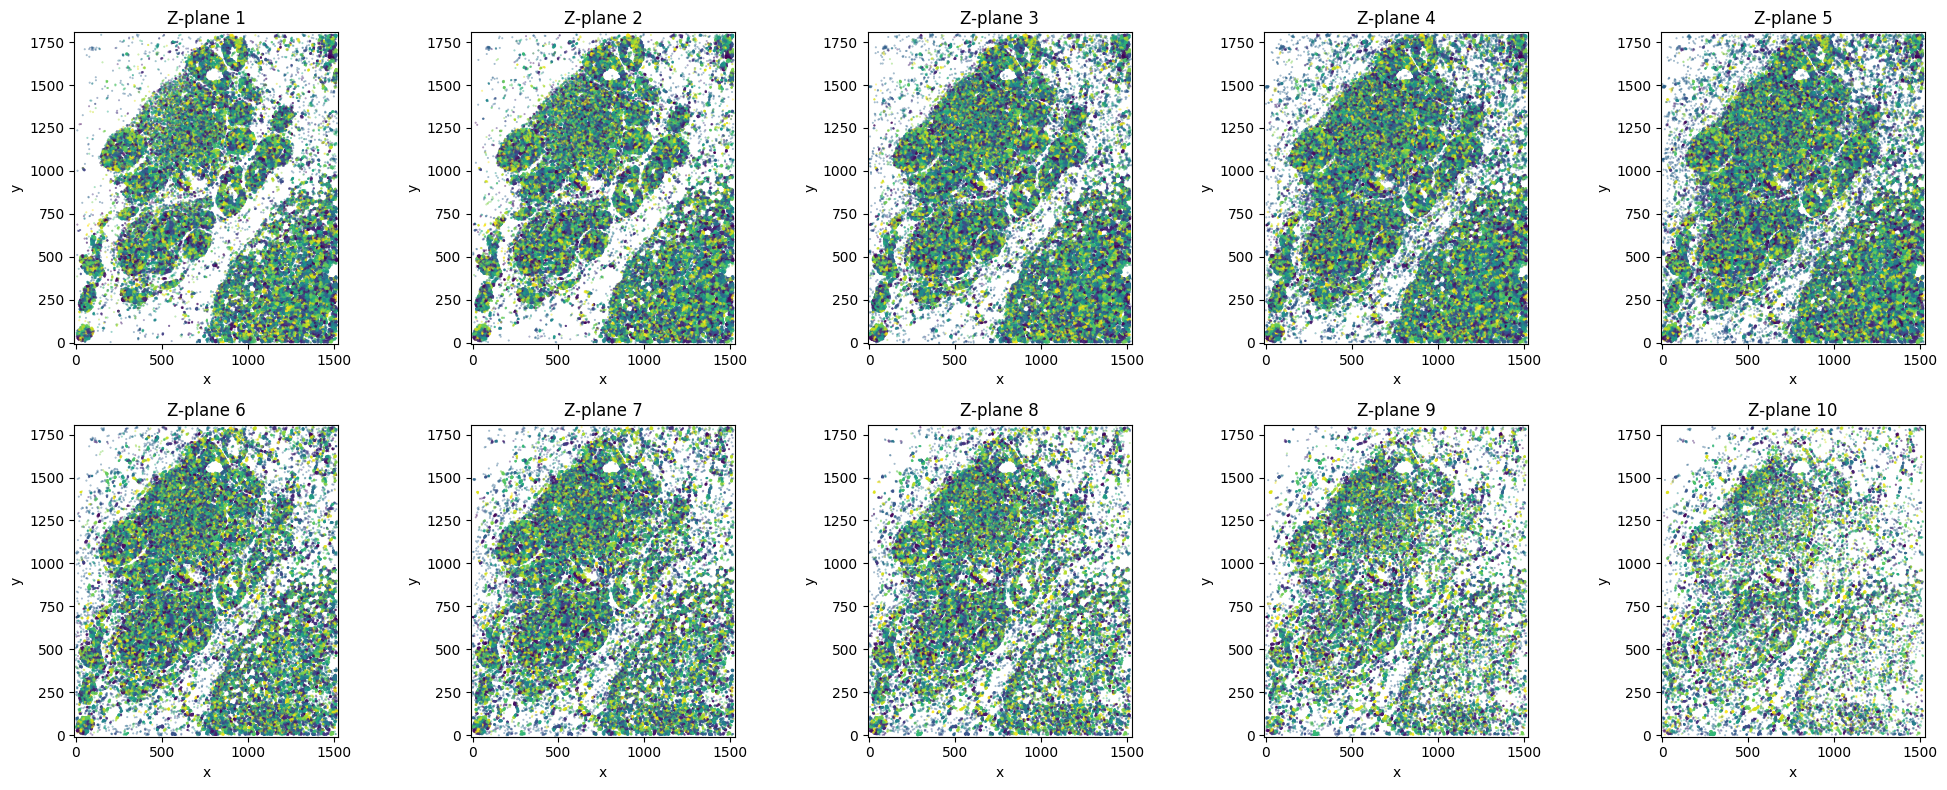

In [ ]:
prefixes = (
    "NegControlProbe_",
    "antisense_",
    "NegControlCodeword_",
    "BLANK_",
    "Blank-",
    "NegPrb",
    "DeprecatedCodeword_",
    "Intergenic_Region_",
    "UnassignedCodeword_",
)

df = sdata["transcripts"].compute()
df = df[~df["feature_name"].str.startswith(prefixes)]

df["z_bin"] = pd.cut(df["z"], bins=10, labels=False)

x_min, x_max = df["x"].min(), df["x"].max()
y_min, y_max = df["y"].min(), df["y"].max()

num_planes = df["z_bin"].nunique()
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

df = df[df["cell_id"] != -1]

unique_ids = df["cell_id"].unique()
n_ids = len(unique_ids)

cmap = cm.get_cmap("viridis", n_ids)
colors = [cmap(i) for i in range(n_ids)]

np.random.shuffle(colors)

id_to_color = dict(zip(unique_ids, colors, strict=False))

for i, ax in enumerate(axes[:num_planes]):
    plane_data = df[df["z_bin"] == i]
    colors = plane_data["cell_id"].map(id_to_color)
    ax.scatter(plane_data["x"], plane_data["y"], c=colors, s=0.2, alpha=0.5)
    ax.set_title(f"Z-plane {i+1}")
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

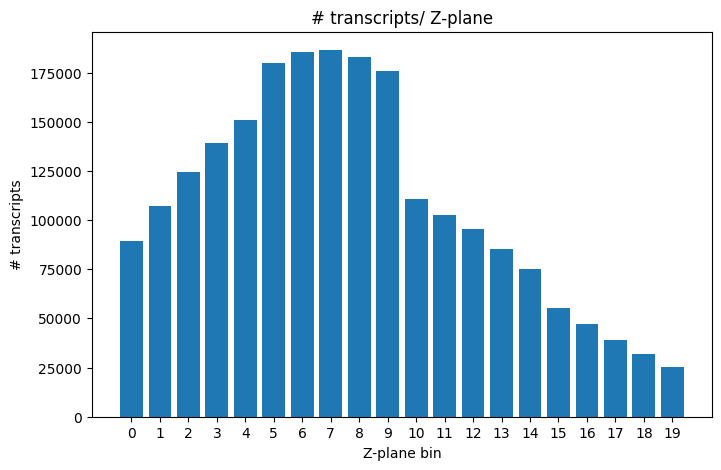

In [6]:
df["z_bin_20"] = pd.cut(df["z"], bins=20, labels=False)

counts = df["z_bin_20"].value_counts().sort_index()

# Plot histogram
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, width=0.8)
plt.xlabel("Z-plane bin")
plt.ylabel("# transcripts")
plt.title("# transcripts/ Z-plane")
plt.xticks(counts.index)
plt.show()

#### Ovrlpy

In [ ]:
coordinate_df = df[["feature_name", "x", "y", "z"]]
coordinate_df = coordinate_df.rename(columns={"feature_name": "gene"})  
coordinate_df["z"] = coordinate_df["z"] - coordinate_df["z"].min()  # shift z to start from 0

In [28]:
coordinate_df.head()

,gene,x,y,z
0,AAMP,17.674686,46.074432,3.225631
1,AAMP,26.841955,193.434400,4.211830
2,AAMP,32.329426,201.935610,1.805348
3,AAMP,62.210957,48.361750,2.288924
4,AAMP,65.758064,33.876854,0.560221


In [29]:
import ovrlpy

ovrlpy_sdata = ovrlpy.Ovrlp(coordinate_df, n_workers=8, random_state=42)

ovrlpy_sdata.analyse()

Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 2837 pseudocells
sampling expression:


100%|██████████| 4/4 [00:26<00:00,  6.66s/it]


Modeling 30 pseudo-celltype clusters;
Creating signal integrity map


100%|██████████| 16/16 [04:59<00:00, 18.69s/it]


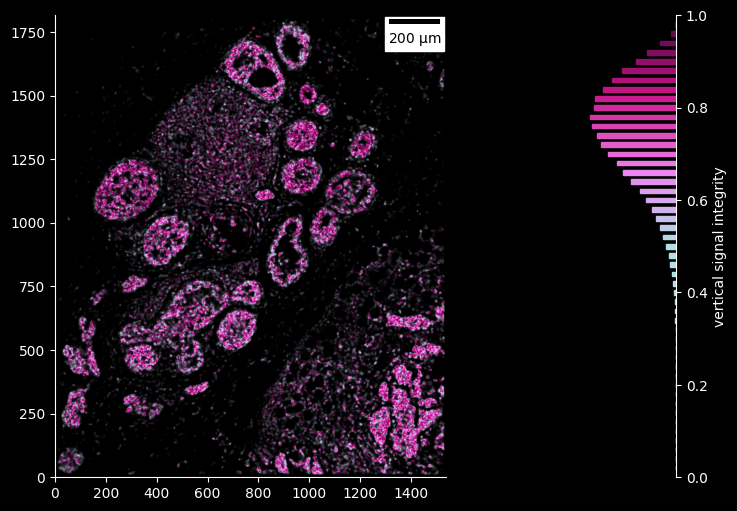

In [43]:
fig = ovrlpy.plot_signal_integrity(ovrlpy_sdata, signal_threshold=3) #setting threhsold to filter out low-transcript regions

In [ ]:
doublets = ovrlpy_sdata.detect_doublets(min_signal=3, integrity_sigma=1)

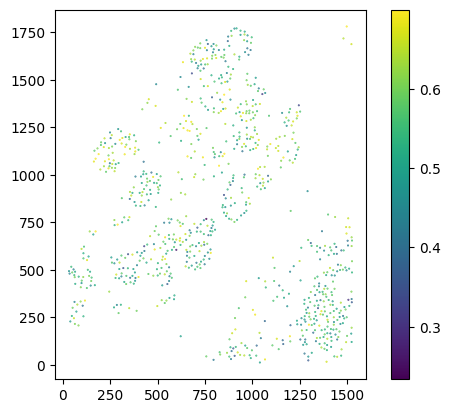

In [40]:
fig, ax = plt.subplots()
_scatter = ax.scatter(
    doublets["x"], doublets["y"], c=doublets["integrity"], s=0.2, cmap="viridis"
)
_ = ax.set_aspect("equal")
_ = fig.colorbar(_scatter, ax=ax)

In [46]:
doublets

x,y,integrity,signal
i64,i64,f32,f32
757,768,0.233776,3.113826
599,605,0.263244,3.005658
1505,342,0.300249,3.050129
1052,1425,0.318916,3.043648
430,624,0.325892,3.092599
…,…,…,…
852,1111,0.697041,3.118522
824,1048,0.697815,3.078462
669,1231,0.698103,3.027988


In [54]:
from __future__ import annotations

from typing import Iterable, Mapping, Union
import numpy as np
import pandas as pd

from shapely.geometry import Point

def count_overlapping_cells_per_doublet(
    sdata,
    doublets: Union[pd.DataFrame, "pl.DataFrame"],
    *,
    x_col: str = "x",
    y_col: str = "y",
    z_keys: Iterable[str] = ("cell_boundaries_z0", "cell_boundaries_z1", "cell_boundaries_z2", "cell_boundaries_z3"),
    cell_id_col: str | None = None,
    buffer: float = 0.0,
) -> pd.DataFrame:
    """
    For each doublet position (x,y), count how many cell boundary polygons overlap it
    in each z-layer stored in sdata.shapes[<z_key>].

    Parameters
    ----------
    sdata
        SpatialData object with shapes for each z-layer.
    doublets
        DataFrame with doublet coordinates.
    x_col, y_col
        Column names in `doublets` for coordinates.
    z_keys
        Shape keys in sdata.shapes to process (one per z layer).
    cell_id_col
        Optional name of a column in shapes gdf that identifies cells.
        If provided, counts unique IDs rather than number of geometries.
    buffer
        If > 0, point is buffered by this radius before intersection tests.
        Useful if points lie exactly on polygon boundaries.

    Returns
    -------
    pd.DataFrame
        Same row order as input doublets, with columns:
        - overlap_<z_key> : number of overlapping cells at that z
        - overlap_total   : sum across z_keys
    """
    # ---- normalize doublets to pandas ----
    if hasattr(doublets, "to_pandas"):  # polars
        doublets_pd = doublets.to_pandas()
    else:
        doublets_pd = doublets.copy()

    if x_col not in doublets_pd.columns or y_col not in doublets_pd.columns:
        raise ValueError(f"doublets must contain columns {x_col!r} and {y_col!r}")

    xs = doublets_pd[x_col].to_numpy()
    ys = doublets_pd[y_col].to_numpy()

    # points geometry (optionally buffered)
    points = [Point(float(x), float(y)) for x, y in zip(xs, ys)]
    if buffer and buffer > 0:
        points_query = [p.buffer(buffer) for p in points]
    else:
        points_query = points

    out = pd.DataFrame(index=doublets_pd.index)

    # ---- loop over z layers ----
    for key in z_keys:
        if key not in sdata.shapes:
            raise KeyError(f"Missing shapes layer {key!r} in sdata.shapes")

        gdf = sdata.shapes[key]

        # Expecting a GeoDataFrame-like object:
        # - gdf.geometry: shapely geometries (polygons)
        # - gdf.sindex: spatial index (rtree/pygeos)
        if not hasattr(gdf, "geometry"):
            raise TypeError(f"sdata.shapes[{key!r}] does not look like a GeoDataFrame (no .geometry)")

        # Build spatial index once
        sidx = getattr(gdf, "sindex", None)
        if sidx is None:
            # geopandas builds it lazily, accessing gdf.sindex creates it
            sidx = gdf.sindex

        counts = np.zeros(len(points_query), dtype=int)

        # For each point, query candidate polygons via bbox, then do exact predicate
        geoms = gdf.geometry.values

        for i, geom in enumerate(points_query):
            # candidates from bbox intersection
            cand_idx = list(sidx.intersection(geom.bounds))
            if not cand_idx:
                continue

            # exact intersection/contain check
            # - if buffer==0, geom is a Point: use contains/covers
            # - if buffer>0, geom is a small Polygon: use intersects
            if buffer and buffer > 0:
                hits = [j for j in cand_idx if geoms[j].intersects(geom)]
            else:
                # covers is often nicer than contains for boundary cases;
                # but some shapely versions differ—intersects(Point) is also fine.
                hits = [j for j in cand_idx if geoms[j].contains(geom)]

            if not hits:
                continue

            if cell_id_col is not None:
                counts[i] = gdf.iloc[hits][cell_id_col].nunique()
            else:
                counts[i] = len(hits)

        out[f"overlap_{key}"] = counts

    out["overlap_total"] = out.filter(like="overlap_").sum(axis=1)

    # optionally attach original x/y (handy for plotting/debug)
    out[x_col] = xs
    out[y_col] = ys

    return out


In [55]:
overlaps = count_overlapping_cells_per_doublet(
    sdata,
    doublets,
    x_col="x",
    y_col="y",
    z_keys=[f"cell_boundaries_z{i}" for i in range(4)],
    cell_id_col="cell_id",   # only if your shapes have this column
    buffer=0.0,              # try 0.5 or 1.0 if you suspect boundary precision issues
)

In [58]:
overlaps

,overlap_cell_boundaries_z0,overlap_cell_boundaries_z1,overlap_cell_boundaries_z2,overlap_cell_boundaries_z3,overlap_total,x,y
0,0,0,0,0,0,757,768
1,1,1,1,1,4,599,605
2,1,1,1,1,4,1505,342
3,0,1,1,1,3,1052,1425
4,1,1,1,1,4,430,624
...,...,...,...,...,...,...,...
859,0,0,1,0,1,852,1111
860,1,0,1,1,3,824,1048
861,0,0,0,0,0,669,1231
862,1,0,0,0,1,1297,211


In [62]:
import numpy as np
import pandas as pd

def unique_cellid_overlap_map_across_z(
    sdata,
    *,
    z_keys=("cell_boundaries_z0","cell_boundaries_z1","cell_boundaries_z2","cell_boundaries_z3"),
    cell_id_col="cell_id",
    pixel_size=2.0,
    all_touched=False,   # True makes polygons "fatter"
):
    """
    Returns:
      overlap: (H,W) uint8 map of number of UNIQUE non-zero cell_ids across z at each pixel
      extent: (minx, maxx, miny, maxy) for plotting with imshow
      labels_stack: (Z,H,W) int32 label images per z (0 background)
    """
    # --- check layers + gather global bounds ---
    gdfs = []
    bounds = []
    for k in z_keys:
        if k not in sdata.shapes:
            raise KeyError(f"Missing shapes layer {k!r} in sdata.shapes")
        gdf = sdata.shapes[k]
        if cell_id_col not in gdf.columns:
            raise KeyError(f"{k!r} missing cell id column {cell_id_col!r}")
        gdfs.append(gdf)
        bounds.append(gdf.total_bounds)  # (minx, miny, maxx, maxy)

    minx = min(b[0] for b in bounds)
    miny = min(b[1] for b in bounds)
    maxx = max(b[2] for b in bounds)
    maxy = max(b[3] for b in bounds)

    width  = int(np.ceil((maxx - minx) / pixel_size))
    height = int(np.ceil((maxy - miny) / pixel_size))

    # --- build a consistent numeric encoding for cell IDs across ALL z ---
    # so that the same cell_id value means the same integer in every plane.
    all_ids = pd.concat([gdf[cell_id_col].astype(str) for gdf in gdfs], ignore_index=True)
    unique_ids = pd.Index(all_ids.unique())
    id_to_int = {cid: i + 1 for i, cid in enumerate(unique_ids)}  # start at 1, reserve 0 for background

    # --- rasterize each plane into a label image ---
    from affine import Affine
    transform = Affine(pixel_size, 0, minx, 0, pixel_size, miny)

    from rasterio.features import rasterize

    labels_stack = np.zeros((len(z_keys), height, width), dtype=np.int32)

    for zi, (k, gdf) in enumerate(zip(z_keys, gdfs)):
        geoms = gdf.geometry.values
        ids   = gdf[cell_id_col].astype(str).values

        shapes = []
        for geom, cid in zip(geoms, ids):
            if geom is None or geom.is_empty:
                continue
            shapes.append((geom, id_to_int[cid]))

        # NOTE: if polygons overlap within the SAME z-plane, rasterize will keep one of them
        # in the overlapping area (last one wins). Proseg boundaries typically shouldn't overlap much.
        labels = rasterize(
            shapes,
            out_shape=(height, width),
            transform=transform,
            fill=0,
            all_touched=all_touched,
            dtype=np.int32,
        )
        labels_stack[zi] = labels

    # --- count unique non-zero ids per pixel across z ---
    # stack shape: (Z,H,W) -> transpose to (H,W,Z)
    A = np.moveaxis(labels_stack, 0, -1)  # (H,W,Z)
    A_sorted = np.sort(A, axis=-1)

    # count changes along Z, ignoring zeros
    # unique count = number of "starts" of new non-zero runs
    nonzero = A_sorted != 0
    starts = nonzero & np.concatenate(
        [np.ones((*A_sorted.shape[:-1], 1), dtype=bool), A_sorted[..., 1:] != A_sorted[..., :-1]],
        axis=-1
    )
    overlap = starts.sum(axis=-1).astype(np.uint8)  # (H,W)

    extent = (minx, maxx, miny, maxy)
    return overlap, extent, labels_stack

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

overlap, extent, _ = unique_cellid_overlap_map_across_z(
    sdata,
    cell_id_col="cell_id",
    pixel_size=2.0,
)

# assume `overlap` is your (H,W) array
max_n = int(overlap.max())

# choose perceptually distinct colors
colors = [
    "#f0f0f0",  # 0: background (light gray)
    "black",  # 1
    "#33a02c",  # 2
    "#e31a1c",  # 3
    "#ff7f00",  # 4
    "#6a3d9a",  # 5 (if needed)
]

colors = colors[: max_n + 1]

cmap = ListedColormap(colors)
bounds = np.arange(-0.5, max_n + 1.5, 1)
norm = BoundaryNorm(bounds, cmap.N)


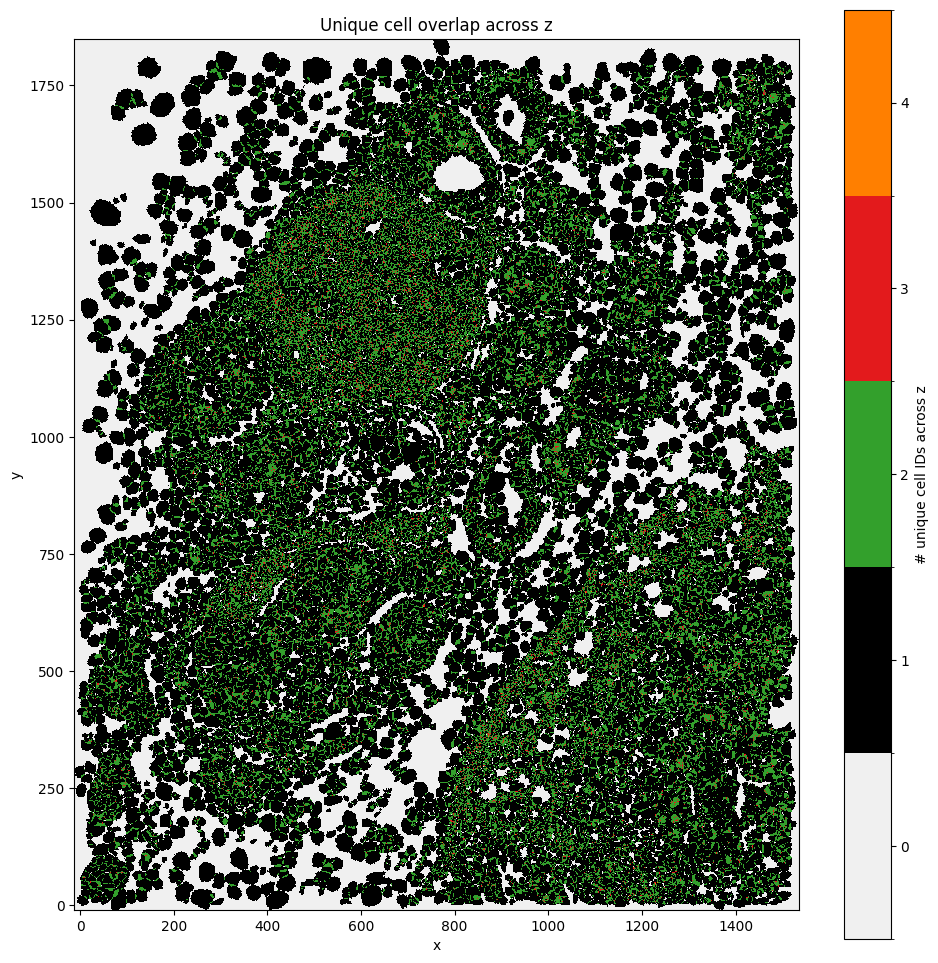

In [69]:
fig, ax = plt.subplots(figsize=(10, 10))  # square, good for tissue

ax.set_facecolor("white")

im = ax.imshow(
    overlap,
    origin="lower",
    extent=extent,
    interpolation="nearest",
    cmap=cmap,
    norm=norm,
)

cbar = fig.colorbar(im, ax=ax, ticks=range(max_n + 1))
cbar.set_label("# unique cell IDs across z")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Unique cell overlap across z")

plt.tight_layout()
plt.show()

## Correlations between the top and bottom of the slice

To assess if there are cells lying on top of each other in the z plane, we can slice our data into a top and bottom plane, e. g. by taking the top 25% and the bottom 25%. We can then compute the Pearson correlation between the two planes for each cell. If the correlation is high, the top and bottom layers likely show the same cell. If it is low, there might be two or more cells overlapping in the z direction.

In [ ]:
st = segtraq.SegTraQ(
    sdata,
    images_key="image",
    points_background_id=0,
    tables_area_volume_key="volume",
    tables_x_key="centroid_x",
    tables_y_key="centroid_y",
)

version mismatch: detected: RasterFormatV02, requested: FormatV04


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:128: UserWarning: Missing 4 cell IDs in shapes: [np.int64(11273), np.int64(10307), np.int64(10308), np.int64(6870)]... These cells are present in tables, but not in shapes. This might lead to inconsistencies in the spatialdata object.
  validate_spatialdata(


In [46]:
correlation_df = st.vl.compute_z_plane_correlation()
# removing the unassigned transcripts
correlation_df = correlation_df[correlation_df.index != 0]
correlation_df.head()

,correlation
cell_id,
1,0.360827
2,-0.001534
3,-0.000375
4,0.046278
5,0.110641


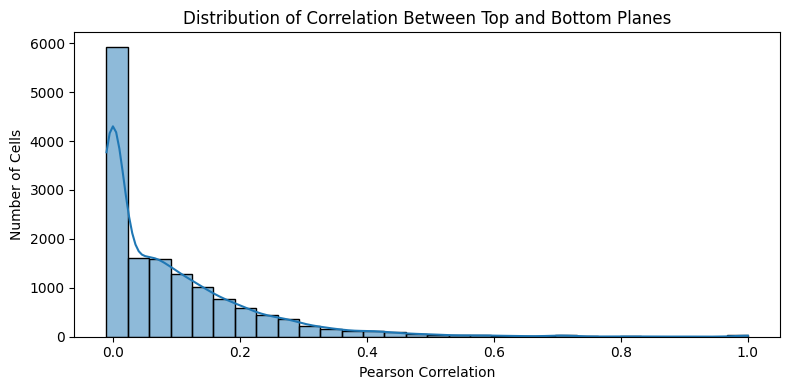

In [47]:
# Plot the distribution of correlation values
plt.figure(figsize=(8, 4))
sns.histplot(correlation_df["correlation"], bins=30, kde=True)

plt.title("Distribution of Correlation Between Top and Bottom Planes")
plt.xlabel("Pearson Correlation")
plt.ylabel("Number of Cells")
plt.tight_layout()
plt.show()

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


Processing IoU between overlapping cells:   0%|          | 0/17881 [17:19<?, ?it/s]


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


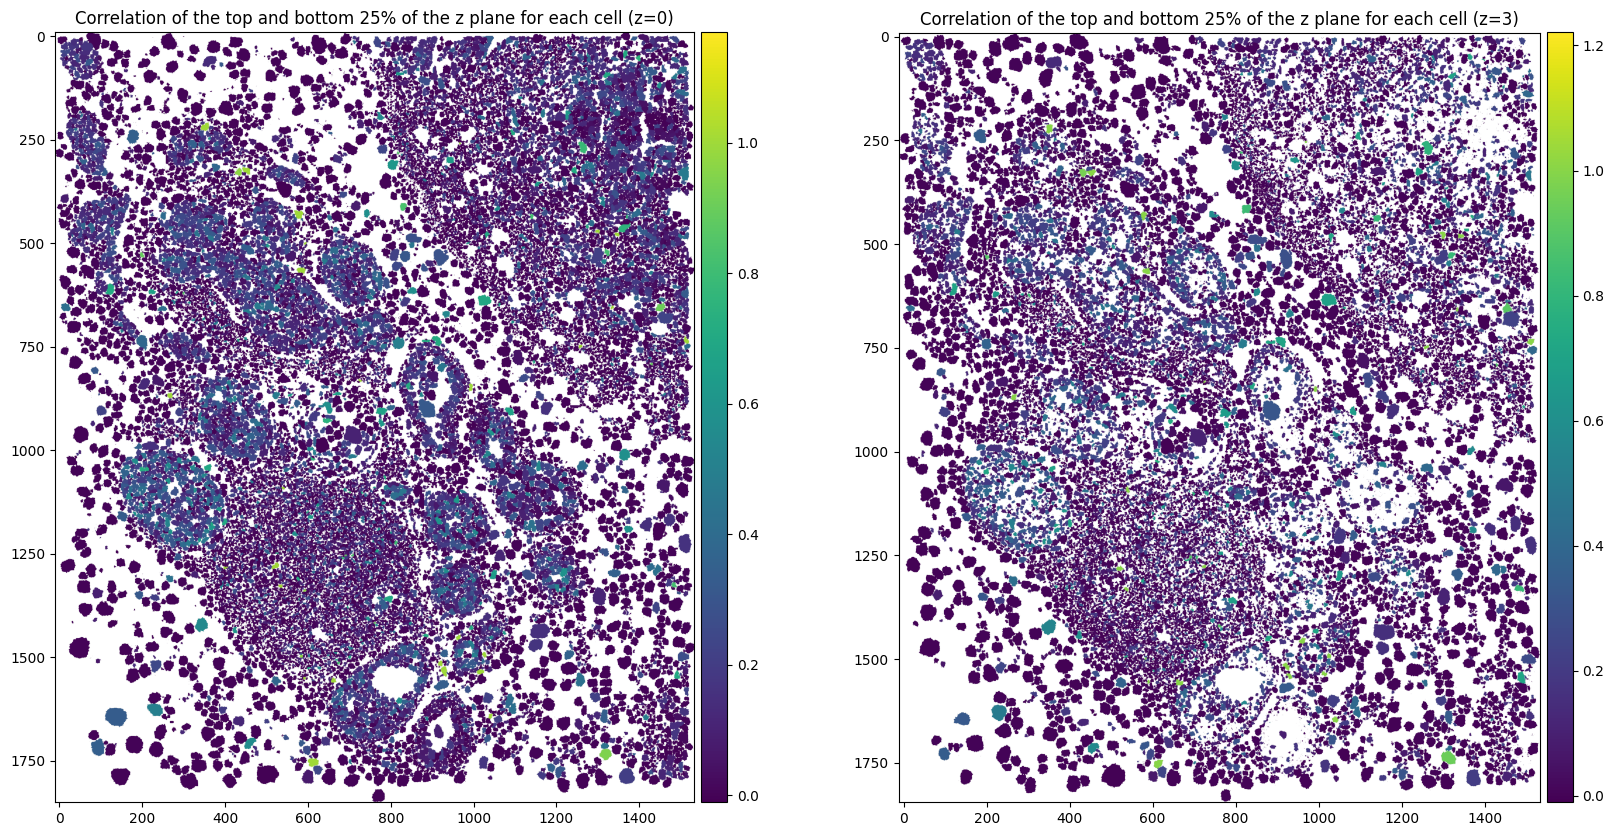

In [48]:
# plotting the correlation on the bottom and top plane respectively
fix, ax = plt.subplots(1, 2, figsize=(20, 10))

sdata_plot = copy.deepcopy(st.sdata)
sdata_plot.tables["table"].obs["region"] = "cell_boundaries_z0"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries_z0")
sdata_plot.pl.render_shapes("cell_boundaries_z0", color="correlation").pl.show(
    title="Correlation of the top and bottom 25% of the z plane for each cell (z=0)",
    coordinate_systems="global",
    ax=ax[0],
)

sdata_plot = copy.deepcopy(st.sdata)
sdata_plot.tables["table"].obs["region"] = "cell_boundaries_z3"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries_z3")
sdata_plot.pl.render_shapes("cell_boundaries_z3", color="correlation").pl.show(
    title="Correlation of the top and bottom 25% of the z plane for each cell (z=3)",
    coordinate_systems="global",
    ax=ax[1],
)

## Assessing physical overlap in 3D

We can assess the overlap of cell segmentation masks in the $z$-dimension by computing the intersetion-over-union (IoU) of a cell with all cell segmentations. This module only works for 3D segmented objects, so e.g. ProSeg. Other segmentations like Xenium only segment object in 2D and hence there is no overlap. The method outputs a list per cell where the length determines the number of overlaps a cell has and the IoU the relative overlap to the cell sizes. Furthermore, we calculate the sum of the IoU values as a measure of the total overlap a cell has. 

In [49]:
IoU_df = st.vl.compute_cell_cell_IoU(inplace=True)
IoU_df.head()

Processing IoU between overlapping cells: 100%|██████████| 17881/17881 [00:48<00:00, 365.61it/s]


,IoU,IoU_sum
cell_id,,
1,"[0.07564600348105502, 0.05148833467417538, 0.0...",0.281033
2,"[0.04936905025459371, 0.01965083916673699, 0.0...",0.079871
3,"[0.149425287356321, 0.08648648648648662, 0.078...",0.486786
4,"[0.027488151658767772, 0.013598637432750256, 0...",0.042182
5,"[0.061946902654866985, 0.0049172999552972736, ...",0.068120


Next, we will visualise the total overlap per cell in physical space. 

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


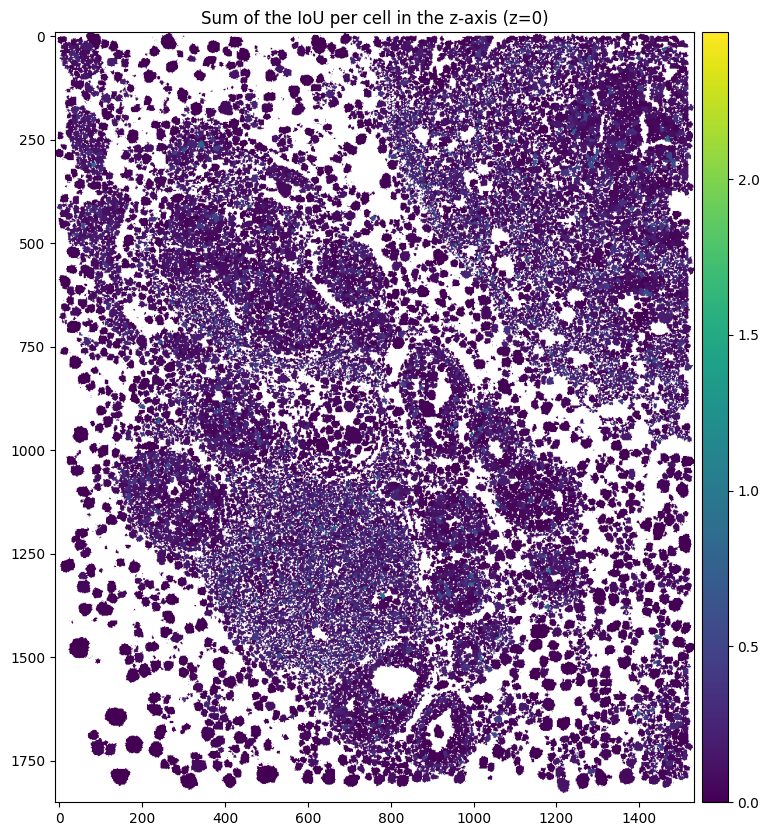

In [51]:
# plotting the correlation on the bottom and top plane respectively
fix, ax = plt.subplots(1, 1, figsize=(10, 10))

sdata_plot = copy.deepcopy(st.sdata)
sdata_plot.tables["table"].obs["region"] = "cell_boundaries_z0"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries_z0")
sdata_plot.pl.render_shapes("cell_boundaries_z0", color="IoU_sum").pl.show(
    title="Sum of the IoU per cell in the z-axis (z=0)",
    coordinate_systems="global",
    ax=ax,
)

You can run all functions in the `vl` module using `run_volume()`.

In [52]:
st.run_volume()
st.sdata.tables["table"].obs

Processing IoU between overlapping cells: 100%|██████████| 17881/17881 [00:50<00:00, 354.00it/s]


,cell_id,centroid_x,centroid_y,centroid_z,volume,label_id,region,correlation,IoU,IoU_sum
0,1,154.66340,1053.593600,-0.115346,1131.674000,1,cell_labels,0.360827,"[0.07564600348105502, 0.05148833467417538, 0.0...",0.281033
1,2,348.67285,287.598750,0.524985,256.049380,2,cell_labels,-0.001534,"[0.04936905025459371, 0.01965083916673699, 0.0...",0.079871
2,3,720.20215,1218.872300,0.660745,148.571900,3,cell_labels,-0.000375,"[0.149425287356321, 0.08648648648648662, 0.078...",0.486786
3,4,877.44590,1707.412100,-0.980020,233.921080,4,cell_labels,0.046278,"[0.027488151658767772, 0.013598637432750256, 0...",0.042182
4,5,1253.77540,1426.495100,0.859675,327.174870,5,cell_labels,0.110641,"[0.061946902654866985, 0.0049172999552972736, ...",0.068120
...,...,...,...,...,...,...,...,...,...,...
17880,17881,1027.99170,123.166664,-1.144839,189.666200,17881,cell_labels,0.000000,"[0.024620741109176836, 0.007439765203739646, 0...",0.042055
17881,17882,1422.56730,47.375000,0.382015,164.377410,17882,cell_labels,0.100298,"[0.011611704598235033, 0.005287508261731808, 0...",0.029509
17882,17883,578.78050,966.006100,0.165542,259.210450,17883,cell_labels,0.203358,"[0.03856749311294766, 0.02576223115102837, 0.0...",0.114530
17883,17884,207.73756,364.975130,0.303928,286.080100,17884,cell_labels,-0.002220,"[0.00888878547079146, 0.0009791498675267663, 0...",0.010683
